# Round 5 — Group strategy exploration

Per-group analyses (everything except `PEBBLES` and `ROBOT`):

1. Basic stats — mid, spread, volume, returns, vol
2. Returns correlation matrix (within group)
3. Common factor (PCA on returns) — variance share of PC1
4. Pair-spread mean reversion — half-life via OU fit + z-score reach
5. Lead-lag cross-correlation between products in the group
6. Trade flow — size distribution, timing, aggressor side, per-product intensity
7. Cross-day stability — does the structure repeat across day 2/3/4?

Plus group-specific parity checks (PANEL has area-arithmetic relationships).

Note: round 5 was supposed to expose bot identities, but the bundled CSVs have empty
buyer/seller (those only populate at runtime in the live submission). So 'bot behavior'
here means flow patterns (size, timing, aggressor side), not identity-by-name.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA = Path('/home/tk/imc-prosperity-4/data/ROUND_5')
DAYS = [2, 3, 4]

In [2]:
GROUPS_ALL: dict[str, list[str]] = {
    'GALAXY_SOUNDS': ['BLACK_HOLES', 'DARK_MATTER', 'PLANETARY_RINGS', 'SOLAR_FLAMES', 'SOLAR_WINDS'],
    'MICROCHIP':     ['CIRCLE', 'OVAL', 'RECTANGLE', 'SQUARE', 'TRIANGLE'],
    'OXYGEN_SHAKE':  ['CHOCOLATE', 'EVENING_BREATH', 'GARLIC', 'MINT', 'MORNING_BREATH'],
    'PANEL':         ['1X2', '1X4', '2X2', '2X4', '4X4'],
    'SLEEP_POD':     ['COTTON', 'LAMB_WOOL', 'NYLON', 'POLYESTER', 'SUEDE'],
    'SNACKPACK':     ['CHOCOLATE', 'PISTACHIO', 'RASPBERRY', 'STRAWBERRY', 'VANILLA'],
    'TRANSLATOR':    ['ASTRO_BLACK', 'ECLIPSE_CHARCOAL', 'GRAPHITE_MIST', 'SPACE_GRAY', 'VOID_BLUE'],
    'UV_VISOR':      ['AMBER', 'MAGENTA', 'ORANGE', 'RED', 'YELLOW'],
}

EXCLUDE = {'PEBBLES', 'ROBOT'}
GROUPS = {g: v for g, v in GROUPS_ALL.items() if g not in EXCLUDE}

def full_symbols(group: str) -> list[str]:
    return [f'{group}_{v}' for v in GROUPS[group]]

ALL_SYMS = [s for g in GROUPS for s in full_symbols(g)]
print(f'{len(GROUPS)} groups, {len(ALL_SYMS)} products')

8 groups, 40 products


In [3]:
# Load all 3 days into a single DataFrame, with day-shifted timestamps so
# day-2 starts at 0, day-3 at 1_000_000, day-4 at 2_000_000 (carry-mode layout).
DAY_TICKS = 1_000_000

def load_prices() -> pd.DataFrame:
    parts = []
    for i, d in enumerate(DAYS):
        df = pd.read_csv(DATA / f'prices_round_5_day_{d}.csv', sep=';')
        df['ts'] = df['timestamp'] + i * DAY_TICKS
        parts.append(df)
    return pd.concat(parts, ignore_index=True)

def load_trades() -> pd.DataFrame:
    parts = []
    for i, d in enumerate(DAYS):
        df = pd.read_csv(DATA / f'trades_round_5_day_{d}.csv', sep=';')
        df['ts'] = df['timestamp'] + i * DAY_TICKS
        df['day'] = d
        parts.append(df)
    return pd.concat(parts, ignore_index=True)

prices = load_prices()
trades = load_trades()
print('prices rows:', len(prices), '| trades rows:', len(trades))
print('products in prices:', prices['product'].nunique())
print('symbols in trades:', trades['symbol'].nunique())

prices rows: 1500000 | trades rows: 35385
products in prices: 50
symbols in trades: 50


In [4]:
# Wide table: rows = ts, columns = product mid_price (for groups we care about).
wide = (
    prices[prices['product'].isin(ALL_SYMS)]
    .pivot_table(index='ts', columns='product', values='mid_price', aggfunc='last')
    .sort_index()
)
wide.head()

product,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_SOLAR_WINDS,MICROCHIP_CIRCLE,MICROCHIP_OVAL,MICROCHIP_RECTANGLE,MICROCHIP_SQUARE,MICROCHIP_TRIANGLE,...,TRANSLATOR_ASTRO_BLACK,TRANSLATOR_ECLIPSE_CHARCOAL,TRANSLATOR_GRAPHITE_MIST,TRANSLATOR_SPACE_GRAY,TRANSLATOR_VOID_BLUE,UV_VISOR_AMBER,UV_VISOR_MAGENTA,UV_VISOR_ORANGE,UV_VISOR_RED,UV_VISOR_YELLOW
ts,,,,,,,,,,,,,,,,,,,,,
0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
100,10007.5,9988.5,9988.5,10002.5,10000.5,9991.5,9999.5,9999.5,9999.5,10000.5,...,9986.5,10015.5,10006.5,10000.5,10002.5,10014.0,10009.5,10003.5,10004.5,9989.5
200,10002.5,10003.5,9995.5,10003.5,10007.5,9993.5,9998.5,10001.5,9999.5,10001.5,...,9996.5,9996.5,10002.5,10002.5,10007.5,10003.5,10017.5,10016.5,10017.5,9985.5
300,10000.5,9994.5,9997.5,10012.5,10021.5,9969.5,9997.5,10002.5,9998.5,10001.5,...,9974.5,9997.5,10010.5,9995.5,10009.5,10009.5,10019.5,10029.5,10014.5,9991.5
400,10005.5,9986.5,10008.5,10012.5,10013.5,9977.5,9996.5,10001.5,10000.5,10000.5,...,9993.5,9993.5,10013.5,9988.5,10019.5,10023.5,10011.5,10032.5,9995.5,9995.5


## Helpers

In [5]:
def basic_stats(df: pd.DataFrame, group_syms: list[str]) -> pd.DataFrame:
    """Per-product mid/spread/volume/return stats over the full dataset."""
    out = []
    for sym in group_syms:
        sub = df[df['product'] == sym]
        if sub.empty:
            continue
        mid = sub['mid_price'].astype(float)
        spread = (sub['ask_price_1'].astype(float) - sub['bid_price_1'].astype(float))
        l1_vol = sub['bid_volume_1'].fillna(0).astype(float) + sub['ask_volume_1'].fillna(0).astype(float)
        ret = mid.pct_change()
        out.append({
            'product': sym,
            'mid_mean': mid.mean(),
            'mid_std':  mid.std(),
            'spread_mean': spread.mean(),
            'spread_p90':  spread.quantile(0.9),
            'l1_vol_mean': l1_vol.mean(),
            'ret_std_bps': ret.std() * 1e4,
            'pnl_per_step': mid.diff().sum() / max(len(mid)-1, 1),
        })
    return pd.DataFrame(out).set_index('product').round(3)

def group_returns(group: str) -> pd.DataFrame:
    syms = full_symbols(group)
    sub = wide[syms].dropna(how='all')
    return sub.pct_change().dropna()

def half_life(spread: pd.Series) -> float:
    """OU half-life via AR(1): dx_t = lambda*(mu - x_{t-1}) dt + eps."""
    s = spread.dropna()
    if len(s) < 200:
        return np.nan
    x = s.shift(1).iloc[1:]
    dx = s.diff().iloc[1:]
    x = x - x.mean()
    beta = (x * dx).sum() / (x * x).sum()
    if beta >= 0:
        return np.inf
    return -np.log(2) / beta

def cross_corr(a: pd.Series, b: pd.Series, max_lag: int = 10) -> dict[int, float]:
    """Pearson corr of a_t vs b_{t+lag} for lag in [-max_lag, max_lag].
    Positive lag means b leads a (a follows b).
    """
    out = {}
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            x, y = a.iloc[-lag:], b.iloc[:lag]
        elif lag > 0:
            x, y = a.iloc[:-lag], b.iloc[lag:]
        else:
            x, y = a, b
        x = x.values; y = y.values
        n = min(len(x), len(y))
        if n < 100:
            out[lag] = np.nan
        else:
            x, y = x[:n], y[:n]
            xv = x - x.mean(); yv = y - y.mean()
            denom = np.sqrt((xv**2).sum() * (yv**2).sum())
            out[lag] = (xv * yv).sum() / denom if denom > 0 else np.nan
    return out

## 1. Basic stats per group

In [6]:
stats_by_group: dict[str, pd.DataFrame] = {}
for g in GROUPS:
    syms = full_symbols(g)
    bs = basic_stats(prices, syms)
    stats_by_group[g] = bs
    print(f'\n=== {g} ===')
    print(bs.to_string())


=== GALAXY_SOUNDS ===
                                mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                                           
GALAXY_SOUNDS_BLACK_HOLES      11466.872  958.445       14.513        16.0       36.513        9.974         0.115
GALAXY_SOUNDS_DARK_MATTER      10226.662  330.701       13.051        14.0       36.513       10.016         0.009
GALAXY_SOUNDS_PLANETARY_RINGS  10766.673  765.837       13.690        15.0       36.513       10.088        -0.012
GALAXY_SOUNDS_SOLAR_FLAMES     11092.572  450.150       14.072        15.0       36.513        9.996         0.027
GALAXY_SOUNDS_SOLAR_WINDS      10437.544  541.111       13.301        14.0       36.513       10.087         0.008



=== MICROCHIP ===
                      mid_mean   mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                                  
MICROCHIP_CIRCLE      9214.885   532.512        8.262         9.0       13.522        9.994         0.013
MICROCHIP_OVAL        8179.599  1551.912        7.450         9.0       15.544       14.989        -0.149
MICROCHIP_RECTANGLE   8732.439   752.019        7.886         9.0       14.444       14.991        -0.041
MICROCHIP_SQUARE     13594.748  1830.252       11.719        14.0       11.915       15.078         0.121
MICROCHIP_TRIANGLE    9686.391   833.370        8.635        10.0       12.876       14.915        -0.069



=== OXYGEN_SHAKE ===
                              mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                                         
OXYGEN_SHAKE_CHOCOLATE        9556.879  560.602       12.185        14.0       36.513       11.170         0.024
OXYGEN_SHAKE_EVENING_BREATH   9271.895  399.821       11.860        12.0       36.513       11.704        -0.019
OXYGEN_SHAKE_GARLIC          11925.640  953.349       15.055        17.0       36.513       10.054         0.130
OXYGEN_SHAKE_MINT             9838.394  508.131       12.594        14.0       36.513       10.038         0.005
OXYGEN_SHAKE_MORNING_BREATH  10000.453  652.805       12.783        14.0       36.513       10.071        -0.015



=== PANEL ===
            mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                       
PANEL_1X2   8922.729  589.917       11.510        13.0       36.513       10.123        -0.010
PANEL_1X4   9397.581  834.033        8.377         9.0       24.376       10.045        -0.026
PANEL_2X2   9576.598  674.795        8.515         9.0       23.663       10.004        -0.020
PANEL_2X4  11265.373  627.191        9.840        11.0       21.736        9.998         0.078
PANEL_4X4   9878.719  457.038        8.750        10.0       22.642       10.076        -0.029



=== SLEEP_POD ===
                      mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                                 
SLEEP_POD_COTTON     11527.614  887.693       10.050        11.0       21.739       10.088         0.047
SLEEP_POD_LAMB_WOOL  10701.442  413.169        9.400        10.0       21.746       10.001         0.027
SLEEP_POD_NYLON       9636.473  508.729        8.565         9.0       23.365        9.971         0.024
SLEEP_POD_POLYESTER  11840.561  977.540       10.296        12.0       21.752       10.014         0.066
SLEEP_POD_SUEDE      11397.420  899.946        9.949        11.0       21.819        9.994         0.060



=== SNACKPACK ===
                       mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                                  
SNACKPACK_CHOCOLATE    9843.372  200.733       16.471        17.0       58.991        6.685        -0.011
SNACKPACK_PISTACHIO    9495.844  187.495       15.926        17.0       58.991        5.518        -0.030
SNACKPACK_RASPBERRY   10077.812  169.814       16.842        18.0       58.991        8.031         0.010
SNACKPACK_STRAWBERRY  10706.608  363.573       17.826        19.0       58.991        7.611         0.030
SNACKPACK_VANILLA     10097.302  178.515       16.869        18.0       58.991        6.452         0.011



=== TRANSLATOR ===
                              mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                                         
TRANSLATOR_ASTRO_BLACK        9385.219  489.746        8.366         9.0       24.098       10.044        -0.035
TRANSLATOR_ECLIPSE_CHARCOAL   9813.742  355.637        8.700         9.0       22.646       10.037        -0.009
TRANSLATOR_GRAPHITE_MIST     10084.640  499.541        8.912        10.0       22.203       10.032        -0.007
TRANSLATOR_SPACE_GRAY         9431.902  502.706        8.402         9.0       23.885        9.982        -0.052
TRANSLATOR_VOID_BLUE         10858.579  579.254        9.525        10.0       21.824        9.961         0.052



=== UV_VISOR ===
                   mid_mean  mid_std  spread_mean  spread_p90  l1_vol_mean  ret_std_bps  pnl_per_step
product                                                                                              
UV_VISOR_AMBER     7911.696  996.918       10.320        12.0       36.540       10.060        -0.096
UV_VISOR_MAGENTA  11111.793  613.554       14.092        15.0       36.513       10.070         0.051
UV_VISOR_ORANGE   10426.506  550.603       13.284        14.0       36.513       10.023        -0.022
UV_VISOR_RED      11063.294  587.715       14.039        15.0       36.513        9.956         0.057
UV_VISOR_YELLOW   10957.461  681.808       13.910        15.0       36.513       10.024         0.002


## 2. Within-group returns correlation

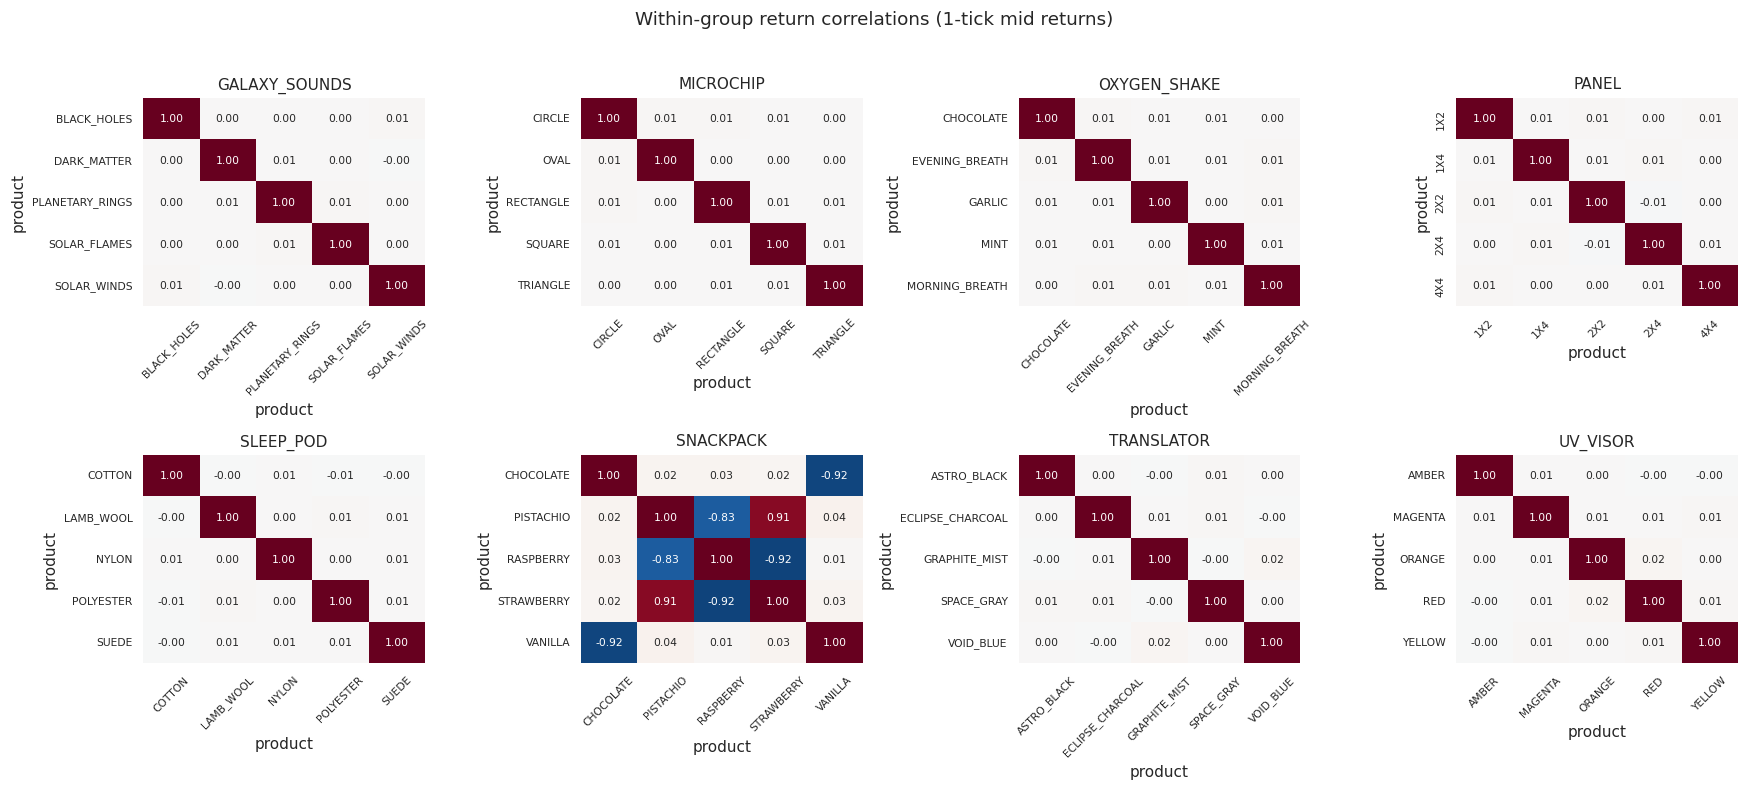

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, g in zip(axes.flat, GROUPS):
    rets = group_returns(g)
    corr = rets.corr()
    short = [c.replace(g + '_', '') for c in corr.columns]
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=short, yticklabels=short, annot=True, fmt='.2f',
                cbar=False, annot_kws={'size': 7})
    ax.set_title(g, fontsize=10)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)
plt.suptitle('Within-group return correlations (1-tick mid returns)', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Mean off-diagonal correlation per group — concise ranking
rows = []
for g in GROUPS:
    c = group_returns(g).corr().values
    n = c.shape[0]
    off = c[~np.eye(n, dtype=bool)]
    rows.append({'group': g, 'mean_corr': off.mean(), 'min_corr': off.min(), 'max_corr': off.max()})
pd.DataFrame(rows).set_index('group').round(3).sort_values('mean_corr', ascending=False)

,mean_corr,min_corr,max_corr
group,,,
OXYGEN_SHAKE,0.007,0.003,0.013
MICROCHIP,0.006,0.002,0.013
UV_VISOR,0.006,-0.002,0.020
GALAXY_SOUNDS,0.004,-0.001,0.013
PANEL,0.004,-0.008,0.011
TRANSLATOR,0.004,-0.005,0.018
SLEEP_POD,0.003,-0.008,0.009
SNACKPACK,-0.160,-0.923,0.913


## 3. PCA — common factor share

In [9]:
def pca_variance(rets: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    X = rets.values
    X = X - X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1
    X = X / sd
    cov = np.cov(X.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]; eigvecs = eigvecs[:, idx]
    return eigvals / eigvals.sum(), eigvecs

rows = []
loadings_by_group = {}
for g in GROUPS:
    rets = group_returns(g)
    var_share, vecs = pca_variance(rets)
    rows.append({'group': g, 'PC1': var_share[0], 'PC2': var_share[1], 'PC3': var_share[2]})
    loadings_by_group[g] = pd.Series(vecs[:, 0], index=rets.columns, name='PC1_loading')
pd.DataFrame(rows).set_index('group').round(3)

,PC1,PC2,PC3
group,,,
GALAXY_SOUNDS,0.204,0.202,0.199
MICROCHIP,0.205,0.200,0.199
OXYGEN_SHAKE,0.206,0.200,0.199
PANEL,0.204,0.202,0.200
SLEEP_POD,0.204,0.202,0.199
SNACKPACK,0.556,0.383,0.039
TRANSLATOR,0.204,0.203,0.200
UV_VISOR,0.206,0.201,0.200


In [10]:
# PC1 loadings (the 'common factor' weights). Uniform loadings = the group is
# basically one asset; lopsided loadings = idiosyncratic structure to exploit.
ld = pd.DataFrame({g: loadings_by_group[g].rename(lambda s: s.replace(g + '_', ''))
                  for g in GROUPS}).round(3)
ld

,GALAXY_SOUNDS,MICROCHIP,OXYGEN_SHAKE,PANEL,SLEEP_POD,SNACKPACK,TRANSLATOR,UV_VISOR
product,,,,,,,,
1X2,NaN,NaN,NaN,0.592,NaN,NaN,NaN,NaN
1X4,NaN,NaN,NaN,0.485,NaN,NaN,NaN,NaN
2X2,NaN,NaN,NaN,0.324,NaN,NaN,NaN,NaN
2X4,NaN,NaN,NaN,0.384,NaN,NaN,NaN,NaN
4X4,NaN,NaN,NaN,0.402,NaN,NaN,NaN,NaN
AMBER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.121
ASTRO_BLACK,NaN,NaN,NaN,NaN,NaN,NaN,-0.243,NaN
BLACK_HOLES,-0.218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHOCOLATE,NaN,NaN,-0.401,NaN,NaN,-0.008,NaN,NaN


## 4. Pair-spread mean reversion (half-life)

For every pair `(i, j)` in a group, fit the spread `mid_i - mid_j` to OU and report
half-life (in ticks). Short half-life with bounded z-score = pairs trade candidate.

In [11]:
def pair_table(group: str) -> pd.DataFrame:
    syms = full_symbols(group)
    sub = wide[syms].dropna()
    rows = []
    for i, a in enumerate(syms):
        for b in syms[i+1:]:
            spread = sub[a] - sub[b]
            z = (spread - spread.mean()) / spread.std()
            rows.append({
                'pair': f'{a.replace(group+"_","")} - {b.replace(group+"_","")}',
                'mean': spread.mean(),
                'std': spread.std(),
                'half_life_ticks': half_life(spread),
                'z_p1': z.quantile(0.01),
                'z_p99': z.quantile(0.99),
                'z_abs_p99': z.abs().quantile(0.99),
            })
    return pd.DataFrame(rows).round(2).sort_values('half_life_ticks')

pair_results = {}
for g in GROUPS:
    print(f'\n=== {g} pair spreads (sorted by half-life) ===')
    pt = pair_table(g)
    pair_results[g] = pt
    print(pt.to_string(index=False))


=== GALAXY_SOUNDS pair spreads (sorted by half-life) ===
                          pair    mean     std  half_life_ticks  z_p1  z_p99  z_abs_p99
    DARK_MATTER - SOLAR_FLAMES -865.91  564.54          1774.98 -2.12   2.09       2.17
     DARK_MATTER - SOLAR_WINDS -210.88  638.57          2616.80 -2.15   1.94       2.16
 DARK_MATTER - PLANETARY_RINGS -540.01  689.88          3527.13 -1.85   2.22       2.22
    SOLAR_FLAMES - SOLAR_WINDS  655.03  811.63          3693.33 -1.77   1.85       1.87
PLANETARY_RINGS - SOLAR_FLAMES -325.90  891.87          5065.99 -2.35   1.80       2.35
 PLANETARY_RINGS - SOLAR_WINDS  329.13  898.17          5473.46 -1.69   1.94       1.97
     BLACK_HOLES - SOLAR_WINDS 1029.33  853.66          8621.94 -1.78   2.51       2.51
     BLACK_HOLES - DARK_MATTER 1240.21 1016.41          8901.19 -1.34   2.57       2.57
    BLACK_HOLES - SOLAR_FLAMES  374.30 1105.57         19105.19 -1.52   2.55       2.55
 BLACK_HOLES - PLANETARY_RINGS  700.20 1181.54              in

In [12]:
# Top 5 fastest-reverting pairs across ALL groups (most tradeable)
all_pairs = []
for g, pt in pair_results.items():
    pt2 = pt.copy()
    pt2['group'] = g
    all_pairs.append(pt2)
merged = pd.concat(all_pairs, ignore_index=True)
merged = merged[(merged['half_life_ticks'] > 0) & (merged['half_life_ticks'] != np.inf)]
merged.nsmallest(15, 'half_life_ticks')[['group', 'pair', 'half_life_ticks', 'std', 'z_abs_p99']]

,group,pair,half_life_ticks,std,z_abs_p99
50,SNACKPACK,RASPBERRY - VANILLA,773.71,243.67,2.52
51,SNACKPACK,CHOCOLATE - PISTACHIO,774.83,200.09,2.44
52,SNACKPACK,PISTACHIO - RASPBERRY,816.45,309.29,2.53
53,SNACKPACK,CHOCOLATE - RASPBERRY,898.29,256.88,2.44
54,SNACKPACK,RASPBERRY - STRAWBERRY,1103.89,460.54,2.82
40,SLEEP_POD,COTTON - POLYESTER,1108.15,473.92,2.15
55,SNACKPACK,CHOCOLATE - VANILLA,1195.09,372.18,2.28
41,SLEEP_POD,POLYESTER - SUEDE,1274.60,503.01,2.02
42,SLEEP_POD,LAMB_WOOL - NYLON,1454.83,471.37,2.42
56,SNACKPACK,STRAWBERRY - VANILLA,1498.76,356.57,2.69


## 5. Lead-lag cross-correlation

For each group, compute peak |corr| at lags ±1..±10 ticks. If peak is at non-zero lag,
one product leads/lags the other and predicts its returns.

In [13]:
def leadlag_table(group: str, max_lag: int = 5) -> pd.DataFrame:
    rets = group_returns(group)
    rows = []
    for i, a in enumerate(rets.columns):
        for b in rets.columns[i+1:]:
            cc = cross_corr(rets[a], rets[b], max_lag=max_lag)
            best_lag = max(cc, key=lambda k: abs(cc[k]) if not np.isnan(cc[k]) else -1)
            rows.append({
                'pair': f'{a.replace(group+"_","")} <-> {b.replace(group+"_","")}',
                'corr_lag0': cc[0],
                'best_lag': best_lag,
                'best_corr': cc[best_lag],
            })
    return pd.DataFrame(rows).round(3).sort_values('best_corr', key=abs, ascending=False)

for g in GROUPS:
    print(f'\n=== {g} lead-lag (top 5 by |best_corr|) ===')
    print(leadlag_table(g).head(5).to_string(index=False))


=== GALAXY_SOUNDS lead-lag (top 5 by |best_corr|) ===
                            pair  corr_lag0  best_lag  best_corr
     DARK_MATTER <-> SOLAR_WINDS     -0.001        -1     -0.017
PLANETARY_RINGS <-> SOLAR_FLAMES      0.013        -2     -0.017
    SOLAR_FLAMES <-> SOLAR_WINDS      0.004         4     -0.016
    BLACK_HOLES <-> SOLAR_FLAMES      0.002         4      0.015
     BLACK_HOLES <-> SOLAR_WINDS      0.009         2     -0.012

=== MICROCHIP lead-lag (top 5 by |best_corr|) ===
               pair  corr_lag0  best_lag  best_corr
    CIRCLE <-> OVAL      0.013         5      0.021
 OVAL <-> RECTANGLE      0.003        -1      0.015
  CIRCLE <-> SQUARE      0.008        -1     -0.013
CIRCLE <-> TRIANGLE      0.003         2     -0.012
SQUARE <-> TRIANGLE      0.008         3     -0.012

=== OXYGEN_SHAKE lead-lag (top 5 by |best_corr|) ===
                             pair  corr_lag0  best_lag  best_corr
EVENING_BREATH <-> MORNING_BREATH      0.009         5     -0.019
      

## 6. Trade flow per group

Round 5 CSVs have empty buyer/seller, so we look at flow patterns: trade count, size
distribution, aggressor side (price vs same-tick mid), inter-arrival time.

In [14]:
# Build a mid lookup keyed on (ts, product) so we can classify aggressor side.
mid_lookup = (
    prices.set_index(['ts', 'product'])['mid_price']
    .to_dict()
)

def classify_trades(syms: list[str]) -> pd.DataFrame:
    sub = trades[trades['symbol'].isin(syms)].copy()
    sub['mid'] = sub.apply(lambda r: mid_lookup.get((r['ts'], r['symbol']), np.nan), axis=1)
    sub['signed'] = np.where(sub['price'] > sub['mid'], +1,
                     np.where(sub['price'] < sub['mid'], -1, 0))
    return sub

flow_rows = []
for g in GROUPS:
    syms = full_symbols(g)
    cl = classify_trades(syms)
    if cl.empty:
        continue
    n = len(cl)
    flow_rows.append({
        'group': g,
        'n_trades': n,
        'mean_size': cl['quantity'].mean(),
        'p99_size':  cl['quantity'].quantile(0.99),
        'pct_above_mid': (cl['signed'] > 0).mean(),
        'pct_below_mid': (cl['signed'] < 0).mean(),
        'pct_at_mid':    (cl['signed'] == 0).mean(),
    })
pd.DataFrame(flow_rows).set_index('group').round(3)

,n_trades,mean_size,p99_size,pct_above_mid,pct_below_mid,pct_at_mid
group,,,,,,
GALAXY_SOUNDS,3665,2.462,4.0,0.488,0.512,0.0
MICROCHIP,2845,1.967,3.0,0.527,0.473,0.0
OXYGEN_SHAKE,3665,2.462,4.0,0.488,0.512,0.0
PANEL,3665,2.462,4.0,0.488,0.512,0.0
SLEEP_POD,3665,2.462,4.0,0.488,0.512,0.0
SNACKPACK,3665,2.462,4.0,0.488,0.512,0.0
TRANSLATOR,3665,2.462,4.0,0.488,0.512,0.0
UV_VISOR,3665,2.462,4.0,0.488,0.512,0.0


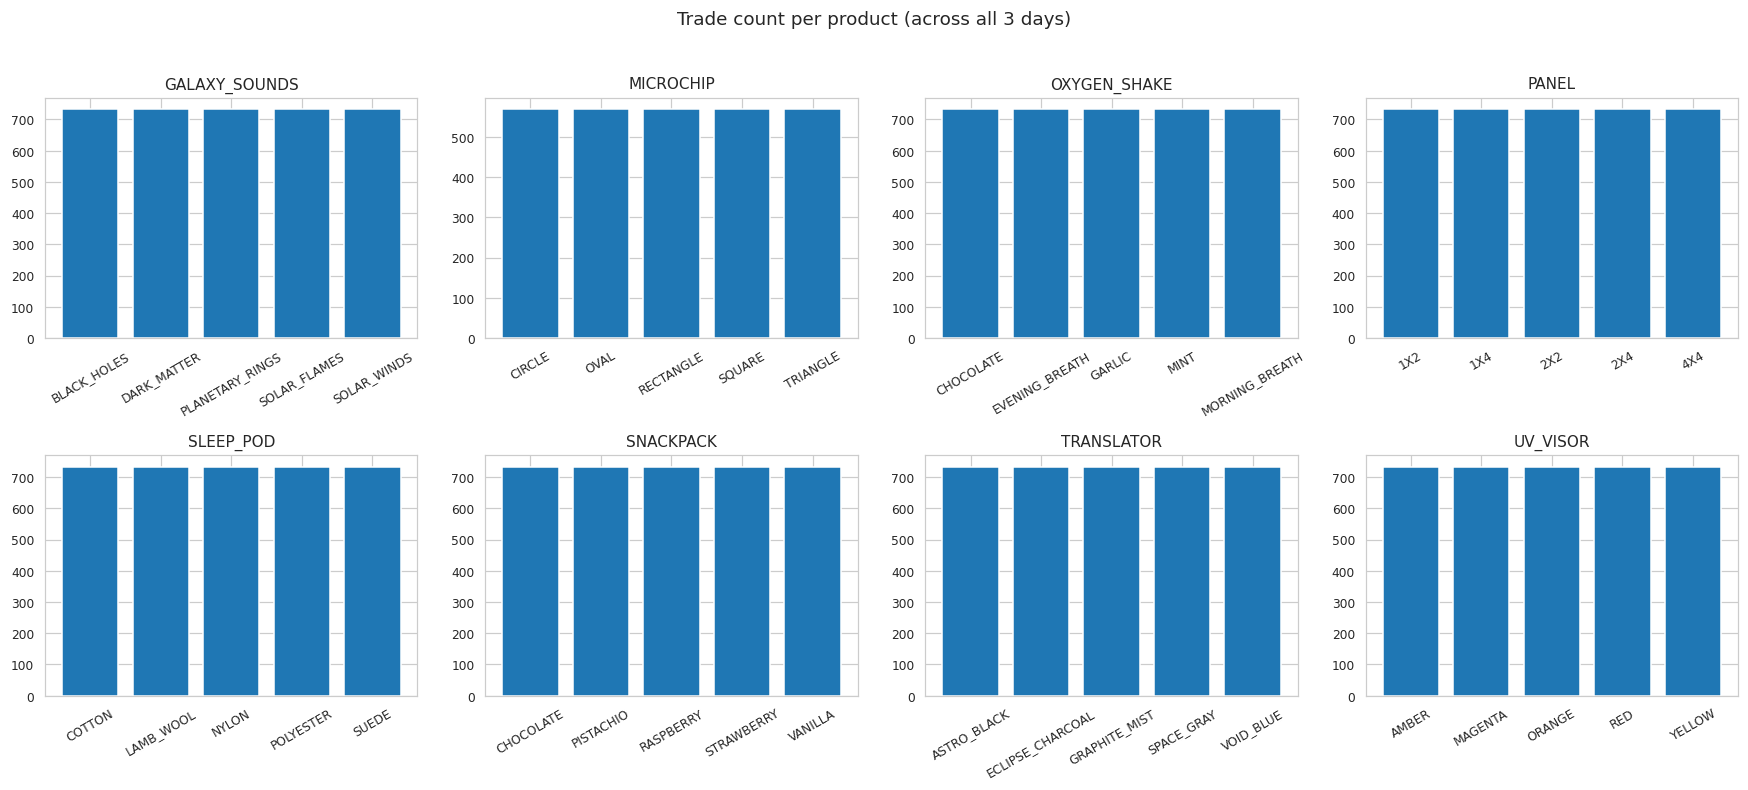

In [15]:
# Per-product trade frequency within each group
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, g in zip(axes.flat, GROUPS):
    syms = full_symbols(g)
    cnt = trades[trades['symbol'].isin(syms)]['symbol'].value_counts().reindex(syms, fill_value=0)
    short = [s.replace(g + '_', '') for s in cnt.index]
    ax.bar(short, cnt.values)
    ax.set_title(g, fontsize=10)
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Trade count per product (across all 3 days)', y=1.02)
plt.tight_layout()
plt.show()

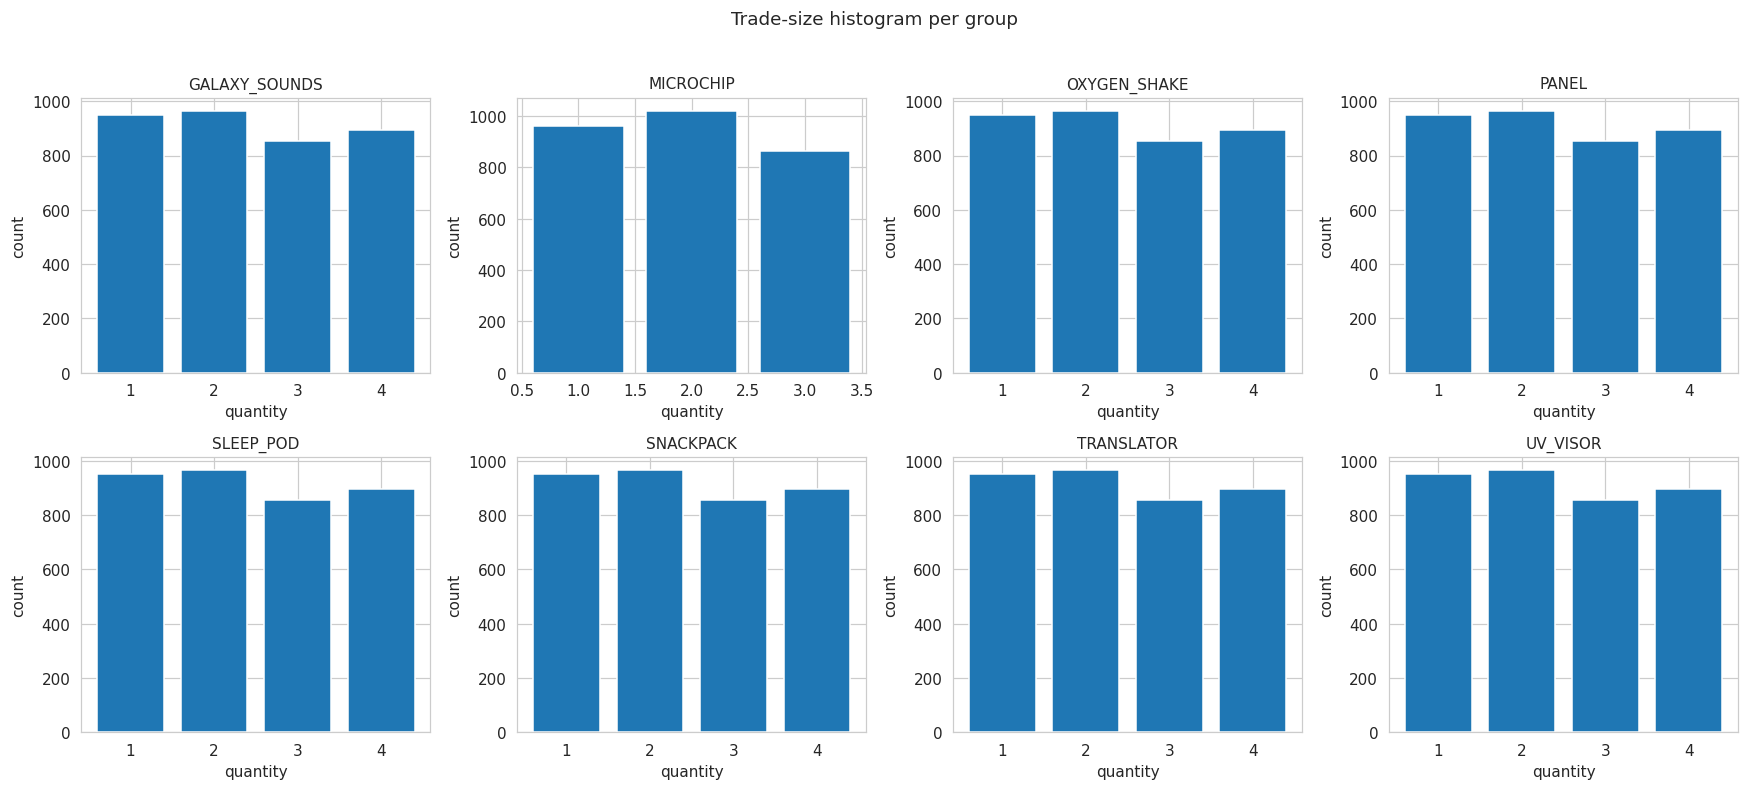

In [16]:
# Trade-size distribution per group (overlaid)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, g in zip(axes.flat, GROUPS):
    syms = full_symbols(g)
    sub = trades[trades['symbol'].isin(syms)]
    sizes = sub['quantity'].value_counts().sort_index()
    ax.bar(sizes.index.astype(int), sizes.values)
    ax.set_title(g, fontsize=10)
    ax.set_xlabel('quantity'); ax.set_ylabel('count')
plt.suptitle('Trade-size histogram per group', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Order flow imbalance over time (rolling): does signed flow predict mid moves?
from collections import defaultdict

def signed_flow_corr(g: str, window: int = 50) -> pd.Series:
    syms = full_symbols(g)
    cl = classify_trades(syms)
    if cl.empty:
        return pd.Series(dtype=float)
    out = {}
    for sym in syms:
        s = cl[cl['symbol'] == sym]
        if len(s) < 200:
            continue
        # Bin by 1000-tick windows
        s = s.sort_values('ts').copy()
        s['bucket'] = (s['ts'] // 10000).astype(int)
        flow = s.groupby('bucket').apply(lambda x: (x['signed'] * x['quantity']).sum())
        # mid change in same bucket
        mids = wide[sym].copy()
        mids.index = (mids.index // 10000).astype(int)
        mid_chg = mids.groupby(level=0).last().diff()
        joined = pd.concat([flow, mid_chg], axis=1, keys=['flow', 'mid_chg']).dropna()
        if len(joined) > 30:
            out[sym] = joined['flow'].corr(joined['mid_chg'])
    return pd.Series(out)

flow_corr_rows = []
for g in GROUPS:
    s = signed_flow_corr(g)
    for sym, v in s.items():
        flow_corr_rows.append({'group': g, 'product': sym.replace(g+'_',''), 'flow_vs_midchg_corr': v})
pd.DataFrame(flow_corr_rows).round(3).pivot_table(index='group', columns='product', values='flow_vs_midchg_corr')

product,1X2,1X4,2X2,2X4,4X4,AMBER,ASTRO_BLACK,BLACK_HOLES,CHOCOLATE,CIRCLE,...,SOLAR_FLAMES,SOLAR_WINDS,SPACE_GRAY,SQUARE,STRAWBERRY,SUEDE,TRIANGLE,VANILLA,VOID_BLUE,YELLOW
group,,,,,,,,,,,,,,,,,,,,,
GALAXY_SOUNDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.043,NaN,NaN,...,-0.067,-0.093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MICROCHIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.034,...,NaN,NaN,NaN,-0.063,NaN,NaN,0.024,NaN,NaN,NaN
OXYGEN_SHAKE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.075,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PANEL,0.145,-0.01,0.013,0.057,-0.013,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLEEP_POD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.082,NaN,NaN,NaN,NaN
SNACKPACK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.054,NaN,...,NaN,NaN,NaN,NaN,0.041,NaN,NaN,0.032,NaN,NaN
TRANSLATOR,NaN,NaN,NaN,NaN,NaN,NaN,-0.029,NaN,NaN,NaN,...,NaN,NaN,0.037,NaN,NaN,NaN,NaN,NaN,-0.006,NaN
UV_VISOR,NaN,NaN,NaN,NaN,NaN,-0.059,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019


## 7. Cross-day stability

Same group, run the correlation matrix per-day. If the structure is stable across
day 2/3/4, you can rely on it; if it flips, regime switching is a real risk.

In [18]:
def per_day_mean_corr(g: str) -> dict[int, float]:
    syms = full_symbols(g)
    out = {}
    for i, d in enumerate(DAYS):
        lo = i * DAY_TICKS
        hi = (i + 1) * DAY_TICKS
        sub = wide.loc[lo:hi-1, syms].dropna(how='all')
        rets = sub.pct_change().dropna()
        if rets.empty:
            out[d] = np.nan
            continue
        c = rets.corr().values
        n = c.shape[0]
        off = c[~np.eye(n, dtype=bool)]
        out[d] = off.mean()
    return out

rows = []
for g in GROUPS:
    pd_corr = per_day_mean_corr(g)
    rows.append({'group': g, **{f'day_{d}_mean_corr': pd_corr[d] for d in DAYS}})
stability = pd.DataFrame(rows).set_index('group').round(3)
stability['day-range'] = (stability.max(axis=1) - stability.min(axis=1)).round(3)
stability

,day_2_mean_corr,day_3_mean_corr,day_4_mean_corr,day-range
group,,,,
GALAXY_SOUNDS,0.001,0.005,0.006,0.005
MICROCHIP,0.007,0.011,0.001,0.010
OXYGEN_SHAKE,0.004,0.006,0.011,0.007
PANEL,0.001,0.009,0.003,0.008
SLEEP_POD,0.004,0.000,0.004,0.004
SNACKPACK,-0.163,-0.159,-0.158,0.005
TRANSLATOR,0.002,0.006,0.005,0.004
UV_VISOR,0.006,0.010,0.002,0.008


## Group-specific: PANEL parity

PANEL skus look like rectangle dimensions. Sq-area arithmetic:

- `1X4` (4 area) ↔ `2X2` (4 area)  → potential equality
- `2X4` (8 area) ↔ 2 × `1X4` (4×2)  → potential 2x-multiple
- `4X4` (16 area) ↔ 2 × `2X4` (8×2) ↔ 4 × `1X4`

If price-per-area is constant within the group, deviations are arb candidates.

In [19]:
panel = wide[full_symbols('PANEL')].dropna()
panel.columns = [c.replace('PANEL_', '') for c in panel.columns]
AREA = {'1X2': 2, '1X4': 4, '2X2': 4, '2X4': 8, '4X4': 16}

# Implied price-per-area per product
ppa = panel / pd.Series(AREA)
print('Mean implied price-per-area (should be ~equal if parity holds):')
print(ppa.mean().round(3))
print('\nSpread of price-per-area across products (sample):')
print(ppa.tail(5).round(3))

Mean implied price-per-area (should be ~equal if parity holds):
1X2    4461.365
1X4    2349.395
2X2    2394.150
2X4    1408.172
4X4     617.420
dtype: float64

Spread of price-per-area across products (sample):
             1X2       1X4       2X2       2X4      4X4
ts                                                     
2999500  4813.50  2317.500  2346.625  1546.188  572.812
2999600  4819.00  2312.250  2345.500  1544.938  572.094
2999700  4824.25  2309.625  2344.750  1546.188  571.875
2999800  4840.50  2307.000  2349.125  1545.062  571.062
2999900  4848.00  2306.875  2348.250  1544.188  570.531


In [20]:
# Same-area pair: 1X4 vs 2X2 — should track identically.
diff_eq_area = panel['1X4'] - panel['2X2']
print('PANEL 1X4 - 2X2 (same area):')
print(f'  mean         : {diff_eq_area.mean():.3f}')
print(f'  std          : {diff_eq_area.std():.3f}')
print(f'  half-life    : {half_life(diff_eq_area):.1f} ticks')
print(f'  |z|>2 frac   : {((diff_eq_area - diff_eq_area.mean()).abs() > 2*diff_eq_area.std()).mean():.3f}')

# 2x relationship: 2X4 vs 2*1X4
diff_2x = panel['2X4'] - 2 * panel['1X4']
print('\nPANEL 2X4 - 2*1X4:')
print(f'  mean         : {diff_2x.mean():.3f}')
print(f'  std          : {diff_2x.std():.3f}')
print(f'  half-life    : {half_life(diff_2x):.1f} ticks')

# 4x relationship: 4X4 vs 4*1X4
diff_4x = panel['4X4'] - 4 * panel['1X4']
print('\nPANEL 4X4 - 4*1X4:')
print(f'  mean         : {diff_4x.mean():.3f}')
print(f'  std          : {diff_4x.std():.3f}')
print(f'  half-life    : {half_life(diff_4x):.1f} ticks')

PANEL 1X4 - 2X2 (same area):
  mean         : -179.018
  std          : 652.491
  half-life    : 3240.7 ticks
  |z|>2 frac   : 0.061

PANEL 2X4 - 2*1X4:
  mean         : -7529.788
  std          : 2107.103
  half-life    : 9955.4 ticks

PANEL 4X4 - 4*1X4:
  mean         : -27711.603
  std          : 3468.958
  half-life    : 9740.4 ticks


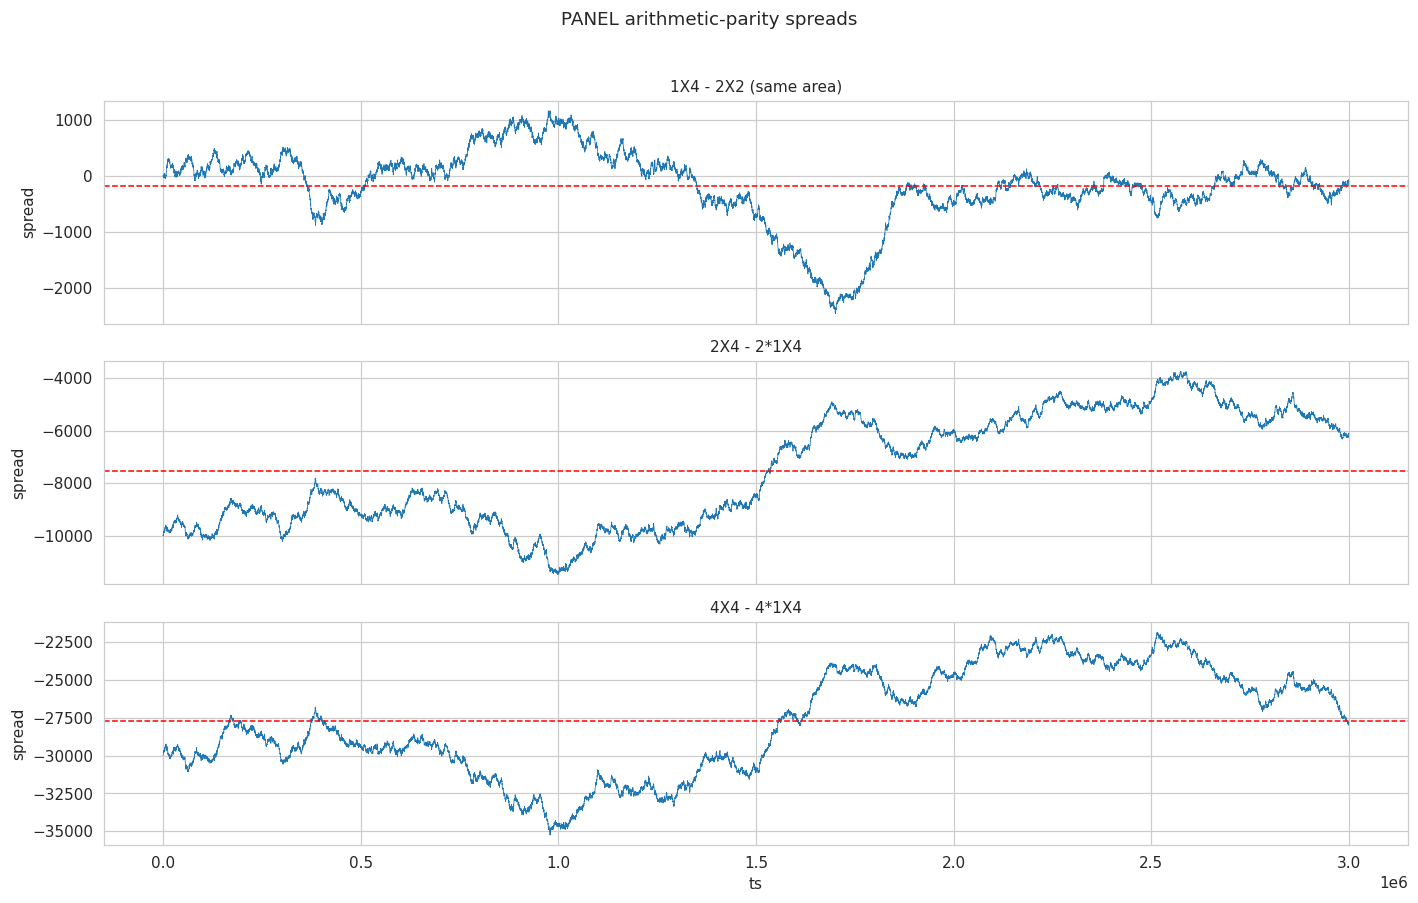

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (label, d) in zip(
    axes,
    [('1X4 - 2X2 (same area)', diff_eq_area),
     ('2X4 - 2*1X4',           diff_2x),
     ('4X4 - 4*1X4',           diff_4x)],
):
    ax.plot(d.index, d.values, lw=0.5)
    ax.axhline(d.mean(), color='red', ls='--', lw=1)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('spread')
axes[-1].set_xlabel('ts')
plt.suptitle('PANEL arithmetic-parity spreads', y=1.02)
plt.tight_layout()
plt.show()

## Summary scoreboard

One-glance table of the strategies each group looks viable for.

In [22]:
scoreboard = []
for g in GROUPS:
    bs = stats_by_group[g]
    rets = group_returns(g)
    c = rets.corr().values
    off = c[~np.eye(c.shape[0], dtype=bool)]
    pc1 = pca_variance(rets)[0][0]
    pt = pair_results[g]
    valid = pt[(pt['half_life_ticks'] > 0) & (pt['half_life_ticks'] != np.inf)]
    fastest = valid['half_life_ticks'].min() if len(valid) else np.nan
    syms = full_symbols(g)
    n_trades = trades[trades['symbol'].isin(syms)].shape[0]
    scoreboard.append({
        'group': g,
        'avg_spread': bs['spread_mean'].mean(),
        'avg_l1_vol': bs['l1_vol_mean'].mean(),
        'mean_corr':  off.mean(),
        'PC1_var_share': pc1,
        'fastest_pair_half_life': fastest,
        'n_trades_3d': n_trades,
    })
pd.DataFrame(scoreboard).set_index('group').round(3)

,avg_spread,avg_l1_vol,mean_corr,PC1_var_share,fastest_pair_half_life,n_trades_3d
group,,,,,,
GALAXY_SOUNDS,13.725,36.513,0.004,0.204,1774.98,3665
MICROCHIP,8.790,13.660,0.006,0.205,2857.06,2845
OXYGEN_SHAKE,12.895,36.513,0.007,0.206,1731.10,3665
PANEL,9.398,25.786,0.004,0.204,2307.92,3665
SLEEP_POD,9.652,22.084,0.003,0.204,1108.15,3665
SNACKPACK,16.787,58.991,-0.160,0.556,773.71,3665
TRANSLATOR,8.781,22.931,0.004,0.204,1618.66,3665
UV_VISOR,13.129,36.518,0.006,0.206,2274.72,3665


### Reading the scoreboard

- **High `avg_spread`** + **high `avg_l1_vol`** → fat market-making target.
- **High `mean_corr`** + **high `PC1_var_share`** → group acts as one asset; basket
  (or single-name with carry) is fine, intra-group pairs add little.
- **Low `mean_corr`** + **fast `fastest_pair_half_life`** → tradeable pairs spread.
- **High `n_trades_3d`** → enough flow to make pair / momentum signals reliable.